# 4.3.2 从平衡到周期的Hopf转变

## 学习目标与先修知识

能连接原点特征值（eigenvalue）、径向方程与周期分支，解释超临界（supercritical） Hopf 转变及临界慢衰减，区分长期半径和单点观测（observation）。

先修：第 4.2 章径向振子及极限环（limit cycle）；第 3 篇复特征值。 [复习上一节](01-平衡分支折叠与滞后.ipynb)。

## 具体问题

调节一个生理反馈（feedback）强度后，原本安静的状态（state）逐步出现节律。怎样在理想模型（model）中把“开始振荡”与一个精确参数（parameter）条件联系起来？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN, GRAY = '#008bfb', '#ff0051', '#009e73', '#555555'

## 初步实验

In [2]:
mus=np.array([-.2,0,.2])
display(Markdown(show_table(['μ','原点特征值实部','非零吸引轨道半径'],[(m,m,np.sqrt(m) if m>0 else 0) for m in mus])))

| μ | 原点特征值实部 | 非零吸引轨道半径 |
| --- | --- | --- |
| -0.2 | -0.2 | 0 |
| 0 | 0 | 0 |
| 0.2 | 0.2 | 0.447214 |

## 模型假设

沿用 x′=(μ−R²)x−ωy、y′=ωx+(μ−R²)y，R²=x²+y²，ω=1；μ 在 [−0.4,0.6] 内变化。状态、时间和 μ 均经尺度归一。

每个 μ 从同一非零初始半径 0.2 起步；比较 τ=10、40 的半径与解析长期半径。每次扫描都重启，不混入历史依赖。这里的 μ 只是理想增长系数，不直接声称等于真实激素、通道电导或反馈增益（gain）。

## 数学解释与推导

原点始终是平衡（equilibrium），雅可比矩阵（Jacobian matrix） 为
$$J(0)=\begin{pmatrix}\mu&-\omega\\\omega&\mu\end{pmatrix},\qquad \lambda=\mu\pm i\omega.$$
μ<0 时附近扰动旋转衰减，μ>0 时旋转增长。仅有这一步还不足以说明增长后去哪里，必须看非线性项。

径向方程 R′=μR−R³ 给出 R=0 及 μ>0 时的 R*=sqrt(μ)。在非零径向平衡，导数（derivative） μ−3R*²=−2μ<0，半径吸引；ω>0 保证沿轨道运动。因此稳定周期分支随 μ 从零正侧连续出现，这是本例的**超临界 Hopf 分岔（Hopf bifurcation）**。若把三次项的符号或更高阶结构改变，仅凭同一线性化（linearization）不能照搬此结论。

一般非退化 Hopf 定理还要求特征值横截虚轴及相应非退化条件；本例的正规形显式满足这些条件。

μ=0 时线性特征值实部恰为零，线性严格判据未决；但 R′=−R³ 的闭式 R=R0/sqrt(1+2R0²τ) 明确趋于零，是代数衰减，比指数衰减慢。短窗口可能将这个慢衰减误看成小振幅（amplitude）极限环。

分岔（bifurcation）图横轴是 μ，纵轴应是长期半径。某个观察时刻的 x=R cosθ 可能正好为零，即使 R 非零。半峰峰值振幅要经过完整周期才接近半径，不能把一个末态 x 当作长期振幅。

还需 ω≠0：如果 ω=0，非零平衡半径上的每个角度都静止，得到一圈平衡，不是周期轨道。本节 μ 分支结论限定在 ω>0 的模型。

折叠与 Hopf 是两种不同转变：前者在开关里使平衡支合并消失，后者在二维模型里使原点失稳并产生小周期。具体判据来自各自方程，而非某种统一的“曲线突然变样”。

## 核心实现

将推导中的每一步明确写成计算。

In [3]:
def radial_exact(mu,omega,initial,times):
    square=initial[0]**2+initial[1]**2
    if square==0:return [[0.,0.] for _ in times]
    states=[]
    for t in times:
        if mu==0:
            radius_square=square/(1+2*square*t)
        else:
            exponent=math.exp(2*mu*t)
            radius_square=square*exponent/(1+square*math.expm1(2*mu*t)/mu)
        scale=math.sqrt(radius_square/square)
        cosine,sine=math.cos(omega*t),math.sin(omega*t)
        states.append([scale*(initial[0]*cosine-initial[1]*sine),scale*(initial[0]*sine+initial[1]*cosine)])
    return states

def hopf_branch(mus,omega):
    radii=[math.sqrt(mu) if mu>0 else 0.0 for mu in mus]
    periods=[2*math.pi/omega if mu>0 else None for mu in mus]
    return radii,periods

## 对照实验

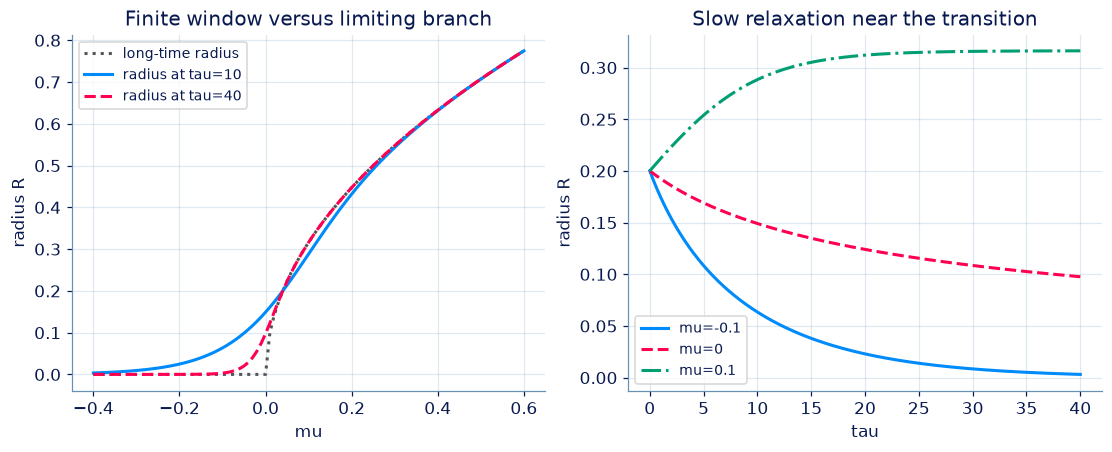

In [4]:
mus=np.linspace(-.4,.6,101)
long_radius,_=hopf_branch(mus,1)
fig,axes=plt.subplots(1,2,figsize=(10,4))
axes[0].plot(mus,long_radius,color=GRAY,ls=':',label='long-time radius')
for end,color,style in [(10,BLUE,'-'),(40,PINK,'--')]:
    finite=[np.linalg.norm(radial_exact(mu,1,[.2,0],[end])[0]) for mu in mus]
    axes[0].plot(mus,finite,color=color,ls=style,label=f'radius at tau={end}')
times=np.linspace(0,40,801)
for mu,color,style in [(-.1,BLUE,'-'),(0,PINK,'--'),(.1,GREEN,'-.')]:
    radius=np.linalg.norm(radial_exact(mu,1,[.2,0],times),axis=1)
    axes[1].plot(times,radius,color=color,ls=style,label=f'mu={mu}')
axes[0].set(xlabel='mu',ylabel='radius R',title='Finite window versus limiting branch')
axes[1].set(xlabel='tau',ylabel='radius R',title='Slow relaxation near the transition')
for ax in axes:ax.legend(fontsize=9)
plt.show()

## 结果解释

左图有限观察曲线在临界附近偏离长期分支；不能把这种偏离自动归咎于求解器，这里用的就是解析轨迹（trajectory）。右图 μ=0 的慢衰减尤其容易造成误读。延长时间与提高算术/积分精度解决的是不同问题。

可把初始半径改为 0：所有 μ 下都会精确保持原点。把这组特殊轨迹与非零初值（initial condition）扫描并列，说明扫描协议为何必须写清。

### 独立核对

用径向方程核对长期半径，用临界特殊解检查慢衰减，再用角周期核对振荡。

In [5]:
for mu in [-.2,0,.2]:
    initial=[.3,.4];t=.7;eps=1e-5
    states=np.array(radial_exact(mu,1,initial,[t-eps,t,t+eps]))
    r=np.linalg.norm(states,axis=1)
    assert abs((r[2]-r[0])/(2*eps)-(mu*r[1]-r[1]**3))<1e-8
assert abs(np.linalg.norm(radial_exact(0,1,[1,0],[4])[0])-1/3)<1e-14
assert hopf_branch([-.2,0,.25],math.pi)==([0.,0.,.5],[None,None,2.])
print('径向微分方程残差、临界闭式和周期分支通过。')

径向微分方程残差、临界闭式和周期分支通过。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/04-03-分岔与参数变化/explore/)：先预测条件变化的后果，再用交互对照本节推导。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：给出长期半径与周期

对 R′=μR−R³、θ′=ω，ω>0。返回非零初值（initial condition）的吸引运动半径：μ≤0 为 0，μ>0 为 sqrt(μ)。没有非零周期轨道时周期返回 None。

**函数与代码模板**

```python
def solve(
    mus: list[float],
    omega: float,
) -> tuple[list[float], list[float | None]]:
    # 根据已知条件计算，并按约定顺序返回。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `mus` | `list[float]` | 需要比较的 μ，保留输入（input）顺序。 | 1 |
| `omega` | `float` | 固定正角速度。 | 1 |

**返回值**

按以下顺序返回元组：(radii, periods)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `radii` | `list[float]` | 对应吸引运动的长期半径。 | 1 |
| `periods` | <code>list[float &#124; None]</code> | 存在非零周期轨道时为 2π/omega，否则 None。 | 1 |

**计算规则**

逐项分支判断 μ>0；不要对 μ≤0 强行开方，不要把原点的固定状态（state）赋予振荡周期。

**约束与边界**

- 所有输入数值有限；不修改输入列表。
- 1≤len(mus)≤30；−1≤mu≤1；0.1≤omega≤3。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| mus | 需要比较的 μ，保留输入（input）顺序。 | [-0.25, 0, 0.25] | 1 |
| omega | 固定正角速度。 | ≈ 3.141593 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
mus = [-0.25, 0, 0.25]
omega = 3.141592653589793

result = solve(mus, omega)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| radii | 对应吸引运动的长期半径。 | [0.0, 0.0, 0.5] | 1 |
| periods | 存在非零周期轨道时为 2π/omega，否则 None。 | [None, None, 2.0] | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0.0, 0.0, 0.5], [None, None, 2.0])
```

**样例解释**

长期半径为 [0,0,0.5]；只有第三项有非零周期轨道，周期为 2，因此 periods=[None,None,2]。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：给出长期半径与周期](http://127.0.0.1:8000/chapters/04-03-%E5%88%86%E5%B2%94%E4%B8%8E%E5%8F%82%E6%95%B0%E5%8F%98%E5%8C%96/practice/?question=p04-hopf-branch)

### 第 2 题 · 多项选择题：μ=0 时为什么不能说不稳定

径向方程 μ=0 时 R′=−R³。哪些成立？

- **A.** 非零半径缓慢趋于 0。
- **B.** 原点线性化（linearization）实部为零，因此一定不稳定。
- **C.** 衰减是代数型 R=R0/sqrt(1+2R0²t)，可能需要很长观察窗。
- **D.** 线性判据不决定本例，但非线性径向方程能决定。

[作答：μ=0 时为什么不能说不稳定](http://127.0.0.1:8000/chapters/04-03-%E5%88%86%E5%B2%94%E4%B8%8E%E5%8F%82%E6%95%B0%E5%8F%98%E5%8C%96/practice/?question=p04-critical-slow)

### 第 3 题 · 单项选择题：有稳定半径就一定是极限环吗

若把径向振子设为 μ>0、ω=0，则 R=sqrt(μ) 上每点都静止。应怎样解释？

- **A.** 这是一圈平衡（equilibrium）点，不是该模型（model）的非平凡周期轨道。
- **B.** 所有点同时变成原点。
- **C.** 只要相图（phase portrait）上是圆，就可以叫极限环（limit cycle）。
- **D.** 仍有周期 2π/0。

[作答：有稳定半径就一定是极限环吗](http://127.0.0.1:8000/chapters/04-03-%E5%88%86%E5%B2%94%E4%B8%8E%E5%8F%82%E6%95%B0%E5%8F%98%E5%8C%96/practice/?question=p04-zero-frequency)

### 第 4 题 · 单项选择题：分岔图的纵轴为何不能混用

比较开关与径向振子的参数（parameter）扫描，哪项正确？

- **A.** 只要无量纲（dimensionless），任何数值都能合成同一物理量。
- **B.** 振子的振幅（amplitude）只由最后一个时刻决定。
- **C.** 开关平衡（equilibrium）状态（state） x 与振子长期半径 R 是不同摘要，应分别标轴。
- **D.** 把振子的单个末态 x 叫长期振幅总是正确。

[作答：分岔图的纵轴为何不能混用](http://127.0.0.1:8000/chapters/04-03-%E5%88%86%E5%B2%94%E4%B8%8E%E5%8F%82%E6%95%B0%E5%8F%98%E5%8C%96/practice/?question=p04-amplitude-axis)

### 第 5 题 · 多项选择题：特征值穿过虚轴以后

原点特征值（eigenvalue）为 μ±iω，ω>0。对于指定的径向模型（model），哪些支持超临界（supercritical） Hopf 转变？

- **A.** 径向三次项的负号决定了本例的幅度饱和。
- **B.** μ 由负变正时原点从吸引变排斥。
- **C.** 稳定周期半径 sqrt(μ) 从零连续出现。
- **D.** 对任意其他非线性项，只要同样线性化（linearization）就必然有同样稳定环。

[作答：特征值穿过虚轴以后](http://127.0.0.1:8000/chapters/04-03-%E5%88%86%E5%B2%94%E4%B8%8E%E5%8F%82%E6%95%B0%E5%8F%98%E5%8C%96/practice/?question=p04-hopf-evidence)